# **1. Mount drive**


In [ ]:
# # Mount drive
# from google.colab import drive
# drive.mount('/content/drive')

# **2. Import Lib**


In [ ]:
import pandas as pd
import joblib
import json

# **3. Load data**


In [ ]:
sample_data = pd.read_csv("/content/drive/MyDrive/ADV_02/capstone_cuoi_khoa/datawarehouse/sample_data.csv")
sample_data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,TARGET,AGE,YEARS_EMPLOYED,CNT_CHILDREN_BINNED,CNT_FAM_MEMBERS_BINNED
0,5008804,M,Y,Y,360000.0,Working,Higher education,Civil marriage,Apartment / Rental & Others,1,0,0,General Laborers,0,32,12,children_0,fam_2
1,5008805,M,Y,Y,360000.0,Working,Higher education,Civil marriage,Apartment / Rental & Others,1,0,0,General Laborers,0,32,12,children_0,fam_2
2,5008806,M,Y,Y,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Service & Sales,0,58,3,children_0,fam_2
3,5008808,F,N,Y,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Service & Sales,0,52,8,children_0,fam_1
4,5008809,F,N,Y,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Service & Sales,0,52,8,children_0,fam_1


In [ ]:
sample_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      60 non-null     int64  
 1   CODE_GENDER             60 non-null     object 
 2   FLAG_OWN_CAR            60 non-null     object 
 3   FLAG_OWN_REALTY         60 non-null     object 
 4   AMT_INCOME_TOTAL        60 non-null     float64
 5   NAME_INCOME_TYPE        60 non-null     object 
 6   NAME_EDUCATION_TYPE     60 non-null     object 
 7   NAME_FAMILY_STATUS      60 non-null     object 
 8   NAME_HOUSING_TYPE       60 non-null     object 
 9   FLAG_WORK_PHONE         60 non-null     int64  
 10  FLAG_PHONE              60 non-null     int64  
 11  FLAG_EMAIL              60 non-null     int64  
 12  OCCUPATION_TYPE         60 non-null     object 
 13  TARGET                  60 non-null     int64  
 14  AGE                     60 non-null     int6

# **4. Load ML model**


In [ ]:
loaded_model = joblib.load("/content/drive/MyDrive/ADV_02/capstone_cuoi_khoa/models/RandomForest_model.pkl")

# **5. Libs for LLM Reasoning pipeline**


In [ ]:
!pip install langgraph langchain langchain-core langchain-openai

In [ ]:
from typing import TypedDict, Sequence, Annotated # agents step
from langgraph.graph import StateGraph, START, END # agents graph
from langchain_core.messages import HumanMessage, AIMessage # model AI, tool: tạo ra hướng dẫn sử dụng cho AI
from langchain_openai import ChatOpenAI # Tổ chức HumamMessage và AIMessage thành 1 template cố định
from langchain_core.prompts import ChatPromptTemplate
import operator # Điều phối

from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import JsonOutputParser
from pydantic import BaseModel, Field

# **6. Define Agent State**


In [ ]:
class AgentState(TypedDict):
  customer_id: int
  customer_data: str
  probability: float
  factors: dict
  explanation: str
  status: str


# **7. Define tools**


## 7.1 Data retrival tool


In [ ]:
def data_retrieval_tool(state: AgentState) -> AgentState:
  customer_id = state["customer_id"]
  customer_data = sample_data[sample_data["ID"]==customer_id]
  customer_data = customer_data.drop(columns=["TARGET"])
  probability = loaded_model.predict_proba(customer_data)[0][1]
  customer_data = customer_data.to_dict(orient="records")[0]

  return {
      "customer_data": customer_data,
      "probability": probability,
      "status": "data_retrieved",
  }


In [ ]:
# Define AI model and using prompt
data_agent_key = "key"

llm = ChatOpenAI(model="gpt-4o-mini", api_key=data_agent_key, temperature=0.2)

# feature analysis prompt
feature_analysis_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a Senior Credit Risk Underwriter. Your task is to explain the credit decision drivers.
    Requirements:
    1. Analyze the applicant's profile and the predicted probability of default.
    2. Extract key factors influencing the credit risk score.
    3. Output must be a valid JSON object: {{"top_factors": [{{"factor": "term", "impact": float, "influence": "Pos/Neg", "insight": "explanation"}}]}}
    Use professional banking terminology. No conversational fillers."""),

    ("user", "Applicant Data: {customer_data}\\nDefault Probability: {probability}\\nExecute Risk Reasoning:"),
])

## 7.2 Feature analysis tool


In [ ]:
def feature_analysis_agent(state: AgentState) -> AgentState:
    probability = state["probability"]
    customer_data = state["customer_data"]

    chain = feature_analysis_prompt | llm | JsonOutputParser()

    try:
        top_factors = chain.invoke({
            "probability": probability,
            "customer_data": json.dumps(customer_data)  # convert dict to string
        })
    except Exception as e:
        print(f"Error in feature_analysis_agent: {e}")
        print(f"Type of probability: {type(probability)}, Type of customer_data: {type(customer_data)}")
        top_factors = {"error": "Parsing failed"}

    return {
        "factors": top_factors,
        "status": "feature_analyzed"
    }

In [ ]:
# explanation prompt
# explanation_prompt = ChatPromptTemplate.from_messages([
#     ("system", """
#         Bạn là một chuyên gia phân tích rủi ro tín dụng. Dựa trên các yếu tố ảnh hưởng được cung cấp, đánh giá khả năng nợ xấu của khách hàng nộp đơn mở thẻ.
#         => Nếu xác suất < 0.25, khách hàng ít có khả năng nợ xấu. Hãy giải thích lý do, chỉ ra các điểm yếu tố chính và chỉ ra vấn đề nằm ở đâu.
#         => Nếu xác suất >= 0.25, khách hàng có nguy cơ nợ xấu. Hãy làm nổi bật các điểm yếu khiến cho khách hàng có nguy cơ nợ xấu.
#         Giữ lời giải thích rõ ràng và ngắn gọn.
#      """),
#     ("user", "Yếu tố ảnh hưởng: {factors}\nXác suất tham gia làm việc: {probability}\nTạo lời giải thích.")
# ])

explanation_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a Senior Credit Underwriter. Based on the factors and PD provided, provide a professional explanation:
    - If PD < 0.25: Highlight Risk Mitigants (strengths) that justify approval.
    - If PD >= 0.25: Highlight Adverse Drivers (risks) that cause the high probability.
    Length: Max 100 words. Tone: Professional Banking."""),
    ("user", "Key Factors: {factors}\nPredicted Probability of Default: {probability}")
])

## 7.3 Explanation tool


In [ ]:
def explanation_agent(state: AgentState) -> AgentState:
    factors = state["factors"]
    probability = state["probability"]

    # Check JSON error in previous step
    if "error" in factors:
        factors_str = f"Unable to parse specific factors. General risk probability is {probability}."
    else:
        # Convert dictionary factors to String for prompt
        factors_str = json.dumps(factors, indent=2)

    chain = explanation_prompt | llm | StrOutputParser()

    try:
        explanation = chain.invoke({
            "factors": factors_str,
            "probability": probability
        })
    except Exception as e:
        explanation = f"Error generating credit explanation: {str(e)}"

    return {
        "status": "explanation_generated",
        "explanation": explanation
    }

# **8. Define Agent Node**


In [ ]:
workflow = StateGraph(AgentState)
workflow.add_node("data_retrieval_tool", data_retrieval_tool)
workflow.add_node("feature_analysis_agent", feature_analysis_agent)
workflow.add_node("explanation_agent", explanation_agent)

# **9. Create connection among nodes**


In [ ]:
workflow.add_edge(START, "data_retrieval_tool")
workflow.add_edge("data_retrieval_tool", "feature_analysis_agent")
workflow.add_edge("feature_analysis_agent", "explanation_agent")
workflow.add_edge("explanation_agent", END)

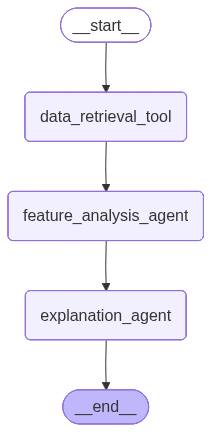

In [ ]:
graph = workflow.compile()
graph

In [ ]:
sample_data.head(100)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,TARGET,AGE,YEARS_EMPLOYED,CNT_CHILDREN_BINNED,CNT_FAM_MEMBERS_BINNED
0,5008804,M,Y,Y,360000.0,Working,Higher education,Civil marriage,Apartment / Rental & Others,1,0,0,General Laborers,0,32,12,children_0,fam_2
1,5008805,M,Y,Y,360000.0,Working,Higher education,Civil marriage,Apartment / Rental & Others,1,0,0,General Laborers,0,32,12,children_0,fam_2
2,5008806,M,Y,Y,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Service & Sales,0,58,3,children_0,fam_2
3,5008808,F,N,Y,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Service & Sales,0,52,8,children_0,fam_1
4,5008809,F,N,Y,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Service & Sales,0,52,8,children_0,fam_1
5,5008810,F,N,Y,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Service & Sales,0,52,8,children_0,fam_1
6,5008811,F,N,Y,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Service & Sales,0,52,8,children_0,fam_1
7,5008812,F,N,Y,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,General Laborers,0,61,0,children_0,fam_1
8,5008813,F,N,Y,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,General Laborers,0,61,0,children_0,fam_1
9,5008814,F,N,Y,283500.0,Pensioner,Higher education,Separated,House / apartment,0,0,0,General Laborers,0,61,0,children_0,fam_1


In [ ]:
result = graph.invoke({"customer_id": 5009628, "status": "start"})
result

{'customer_id': 5009628,
 'customer_data': {'ID': 5009628,
  'CODE_GENDER': 'F',
  'FLAG_OWN_CAR': 'N',
  'FLAG_OWN_REALTY': 'N',
  'AMT_INCOME_TOTAL': 238500.0,
  'NAME_INCOME_TYPE': 'Working',
  'NAME_EDUCATION_TYPE': 'Secondary / secondary special',
  'NAME_FAMILY_STATUS': 'Married',
  'NAME_HOUSING_TYPE': 'House / apartment',
  'FLAG_WORK_PHONE': 1,
  'FLAG_PHONE': 0,
  'FLAG_EMAIL': 0,
  'OCCUPATION_TYPE': 'General Laborers',
  'AGE': 52,
  'YEARS_EMPLOYED': 9,
  'CNT_CHILDREN_BINNED': 'children_0',
  'CNT_FAM_MEMBERS_BINNED': 'fam_2'},
 'probability': np.float64(0.3237563913209328),
 'factors': {'top_factors': [{'factor': 'Income Level',
    'impact': 0.25,
    'influence': 'Pos',
    'insight': 'The applicant has a high annual income of 238,500, which positively influences their ability to repay debts.'},
   {'factor': 'Employment Stability',
    'impact': 0.2,
    'influence': 'Pos',
    'insight': 'With 9 years of employment in a stable occupation, this indicates reliability a

In [ ]:
print(result)

{'customer_id': 5008806, 'customer_data': {'ID': 5008806, 'CODE_GENDER': 'M', 'FLAG_OWN_CAR': 'Y', 'FLAG_OWN_REALTY': 'Y', 'AMT_INCOME_TOTAL': 112500.0, 'NAME_INCOME_TYPE': 'Working', 'NAME_EDUCATION_TYPE': 'Secondary / secondary special', 'NAME_FAMILY_STATUS': 'Married', 'NAME_HOUSING_TYPE': 'House / apartment', 'FLAG_WORK_PHONE': 0, 'FLAG_PHONE': 0, 'FLAG_EMAIL': 0, 'OCCUPATION_TYPE': 'Service & Sales', 'AGE': 58, 'YEARS_EMPLOYED': 3, 'CNT_CHILDREN_BINNED': 'children_0', 'CNT_FAM_MEMBERS_BINNED': 'fam_2'}, 'probability': np.float64(0.00955818044382726), 'factors': {'top_factors': [{'factor': 'AMT_INCOME_TOTAL', 'impact': 0.25, 'influence': 'Pos', 'insight': 'A higher total income indicates a greater ability to meet financial obligations, positively influencing creditworthiness.'}, {'factor': 'AGE', 'impact': 0.2, 'influence': 'Pos', 'insight': 'An older applicant may have more financial stability and experience, contributing positively to the credit risk assessment.'}, {'factor': 'YE

In [ ]:
customer_data = pd.DataFrame(result['customer_data'], index=[0])
customer_data

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,AGE,YEARS_EMPLOYED,CNT_CHILDREN_BINNED,CNT_FAM_MEMBERS_BINNED
0,5009628,F,N,N,238500.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,General Laborers,52,9,children_0,fam_2


In [ ]:
factors_df = pd.DataFrame(result['factors'])
factors_df = factors_df['top_factors'].apply(pd.Series)
factors_df

,factor,impact,influence,insight
0,Income Level,0.25,Pos,"The applicant has a high annual income of 238,..."
1,Employment Stability,0.20,Pos,With 9 years of employment in a stable occupat...
2,Age,0.15,Neg,"At 52 years old, there may be concerns regardi..."
3,Family Status,0.10,Pos,Being married may suggest a dual income househ...
4,Ownership of Assets,0.10,Neg,The absence of owned real estate or vehicles m...
5,Occupation Type,0.05,Neg,Working as a General Laborer may be associated...
6,Communication Channels,0.05,Neg,Lack of a phone or email may hinder communicat...
7,Dependents,0.05,Neg,Having no children may reduce financial obliga...


In [ ]:
print(f"Default rate of customer (ID={result['customer_id']}): {result['probability']:.4f}")
print(f"Explanation of credit risk decision:")
# sentence break
print(result['explanation'].replace(". ", ".\n"))

Default rate of customer (ID=5009628): 0.3238
Explanation of credit risk decision:
Given the predicted probability of default (PD) of 0.32, several adverse drivers contribute to this elevated risk.
The applicant's age raises concerns about future income stability, particularly as they approach retirement.
Additionally, the lack of owned assets limits collateral availability, increasing perceived risk.
The occupation as a General Laborer may also indicate lower job security and income variability.
Furthermore, the absence of reliable communication channels could hinder effective financial management.
These factors collectively suggest a higher likelihood of default, warranting careful consideration in the approval process.
